# Polynomial Regression

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pylab as pl

In [3]:
df = pd.read_csv("../data/FuelConsumption.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [4]:
cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
cdf.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


In [7]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

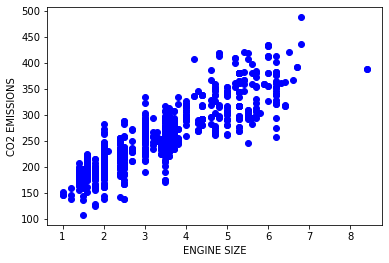

In [8]:
plt.scatter(train["ENGINESIZE"], train["CO2EMISSIONS"], color="blue")
plt.xlabel("ENGINE SIZE")
plt.ylabel("CO2 EMISSIONS")
plt.show()

In [11]:
from sklearn.preprocessing import PolynomialFeatures
train_x = np.array(train[["ENGINESIZE"]])
test_x = np.array((test[["ENGINESIZE"]]))
train_y = np.array(train[["CO2EMISSIONS"]])
test_y = np.array(test[["CO2EMISSIONS"]])

poly = PolynomialFeatures(degree=2)
train_x_poly = poly.fit_transform(train_x)
train_x_poly

array([[ 1.  ,  2.4 ,  5.76],
       [ 1.  ,  1.5 ,  2.25],
       [ 1.  ,  3.5 , 12.25],
       ...,
       [ 1.  ,  3.  ,  9.  ],
       [ 1.  ,  3.2 , 10.24],
       [ 1.  ,  3.2 , 10.24]])

In [12]:
from sklearn import linear_model
clf = linear_model.LinearRegression()
clf.fit(train_x_poly, train_y)

print(clf.coef_)
print(clf.intercept_)

[[ 0.         49.77158358 -1.44584242]]
[108.99158573]


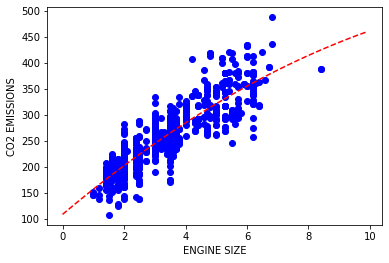

In [21]:
plt.scatter(train_x, train_y, color="blue")
xx = np.arange(0, 10, 0.1)
yy = clf.intercept_[0] + clf.coef_[0][1]*xx + clf.coef_[0][2]*np.power(xx,2)
plt.plot(xx, yy, '--r')
plt.xlabel("ENGINE SIZE")
plt.ylabel("CO2 EMISSIONS")
plt.show()

In [22]:
from sklearn.metrics import r2_score
test_x_poly = poly.fit_transform(test_x)
y_hat = clf.predict(test_x_poly)

print(f"R2: {r2_score(test_y, y_hat): .2f}")

R2:  0.76
